In this notebook I will analyze the data in the movies datasets used for the recommendation systsem. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dir = "ml-latest//"
movies = pd.read_csv(dir + "movies.csv")
tags = pd.read_csv(dir + "tags.csv")

movies = movies[movies["genres"] != "(no genres listed)"].reset_index(drop=True)
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)$")
movies["title"] = movies["title"].str.replace(r"\(\d{4}\)$", "", regex=True).str.strip()
movies["year"] = pd.to_numeric(movies["year"], errors="coerce")
movies["genres"] = movies["genres"].str.replace("|", " ", regex=False)
tags = tags.drop(columns=["userId","timestamp"])

## The Movies

### Genre Counts
We see here that Drama dominates the genre frequency, but being a more generic description it can apply to most movies, since it describes the genral feel of the movie rather than a theme as other genres like sci-fi or war do, one could even divide between feeling (drama, comedy, action/thriller, romance, horror), theme(crime, adventure, fantasy, mystery), sub-genres(sci-fi(a sub-genre of fantasy), war(drama/action), noir(crime/mystery),western(action/adventure/crime)), and types (Documentary, Animation, Musical, IMAX) which describe more the type of movie rather than its content. 

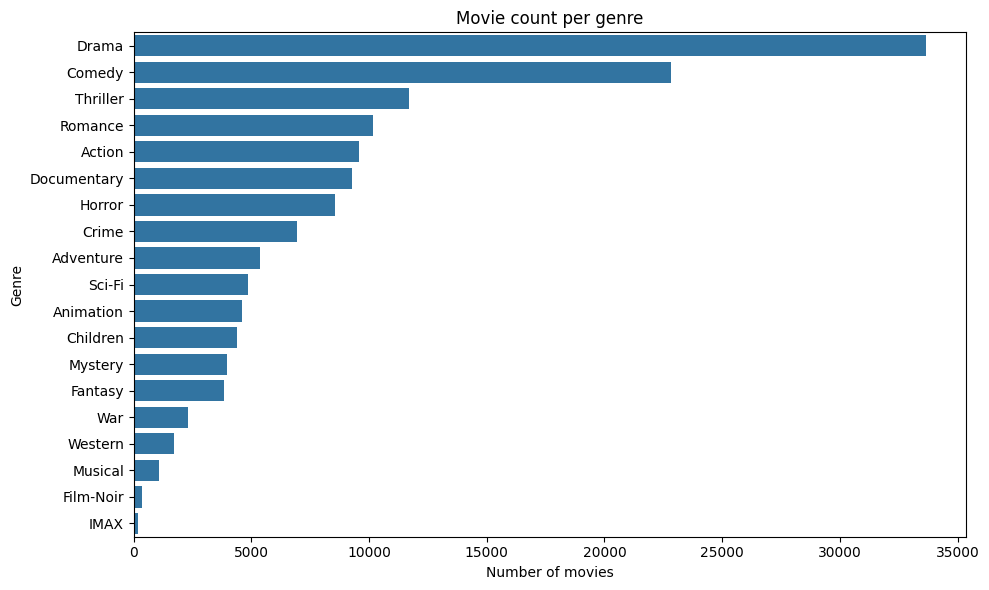

In [8]:
genre_counts = movies["genres"].str.split().explode().value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Movie count per genre")
plt.xlabel("Number of movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### Year Frequency
We can see the years frequency is very skewed towards recent years and it makes sense sicne the movie production increased exponentially in the last few decades. We can even see the effects of the COVID and the strikes (WGA, SAG-AFTRA and VFX) from 2021-2023 with a huge drop bringing the level back 30 years to the early '90s.

count    79081.000000
mean      1995.634957
std         25.727651
min       1874.000000
25%       1981.000000
50%       2006.000000
75%       2015.000000
max       2023.000000
Name: year, dtype: float64


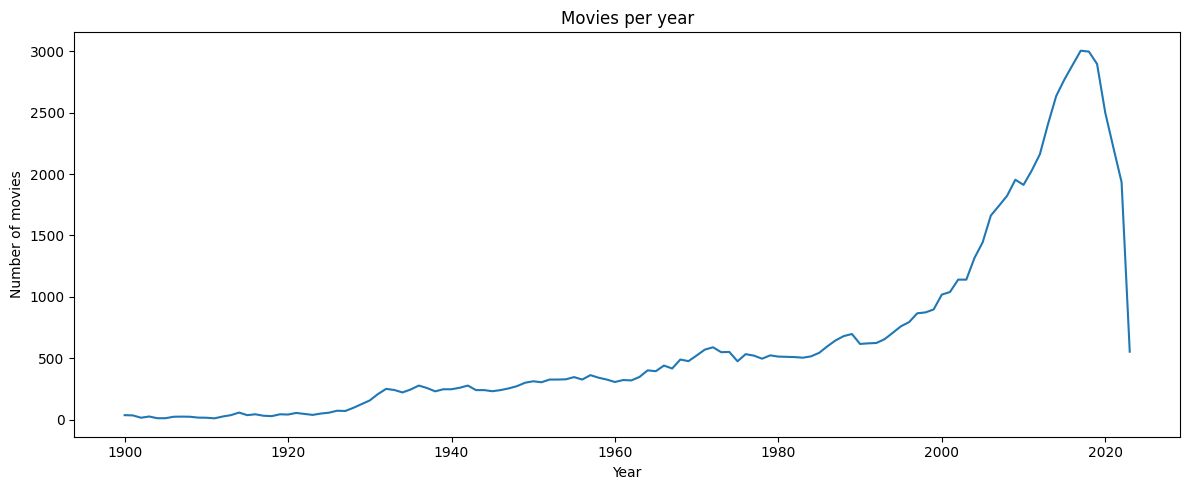

In [10]:
print(movies["year"].describe())
year_counts = movies[movies["year"] >= 1900]["year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values)
plt.title("Movies per year")
plt.xlabel("Year")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()

## Tags

In [12]:
tags = tags.dropna(subset=["tag"])
tags_grouped = tags.groupby("movieId")["tag"].apply(lambda x: " ".join(x)).reset_index()
movies_with_tags = movies.merge(tags_grouped, on="movieId", how="left")
covered = movies_with_tags["tag"].notna().sum()
not_covered = movies_with_tags["tag"].isna().sum()
print(covered, not_covered)

50662 28815


### Movies with at least 1 tag
With a great collection of movies it makes sense that many do not have tags, especially non-blockbuster productions and older less popular movies. We can see that covers over 1/3 of the collection, and considering the increase in production we've seen before, it fits the data. 1/3 can cover older movies and more obscure productions. 

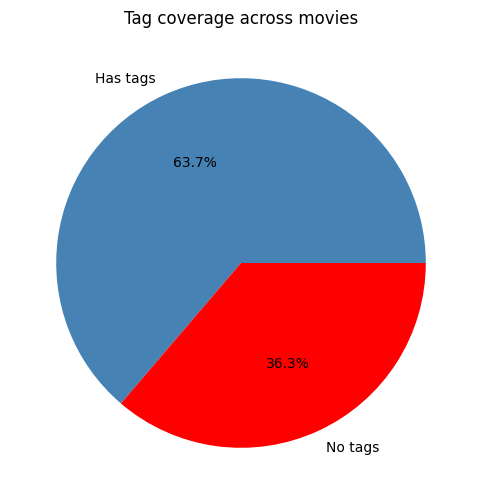

In [14]:
plt.figure(figsize=(6, 6))
plt.pie([covered, not_covered], 
        labels=["Has tags", "No tags"], 
        autopct="%1.1f%%",
        colors=["steelblue", "red"])
plt.title("Tag coverage across movies")
plt.show()

### Top 20 most frequent tags
HEre we can see how some tags merge with genres and that actually reinforces my previous observation about how some genres can be seen as secondary or sub-genres. The fact that scifi is the msot common tag could suggest scifi fans are often (just my speculation) more computer-oriented people so more likely to get involved in tagging movies. It's also true that in the late 2000s with the rise on computer technology and effects, cgi and so on, there has been a huge amount of scifi movies produced, the brief boom of 3D movies like Avatar marked the turning point for science fiction. 

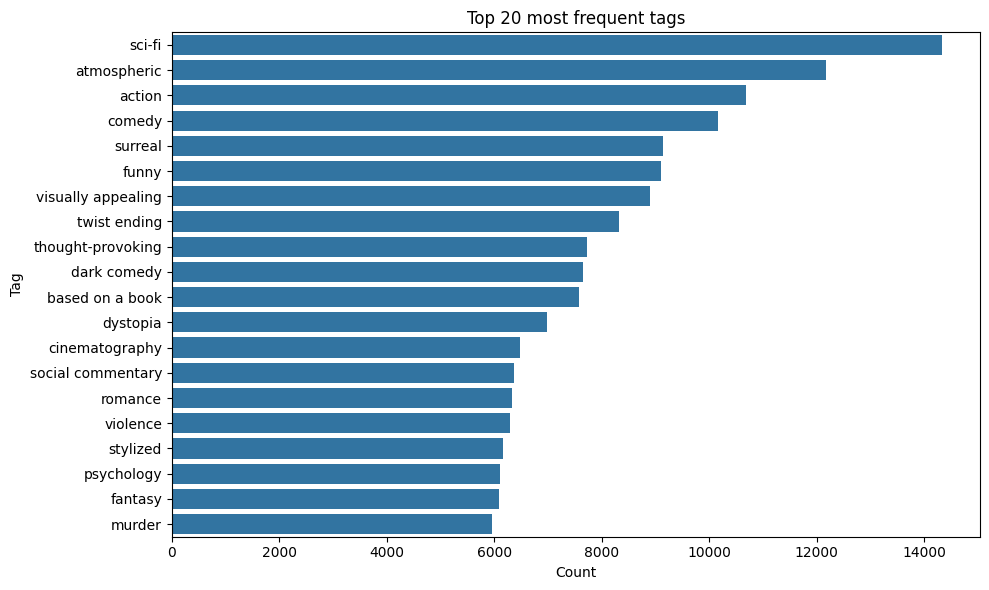

In [15]:
top_tags = tags["tag"].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_tags.values, y=top_tags.index)
plt.title("Top 20 most frequent tags")
plt.xlabel("Count")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()

### Tags per genre

Here we see how Drama still dominates the statistic, and again, being the most generic of genres it covers the biggest chunk of the movies. The rest of the chart follows more or less the general frequency of genres overall, with some variation

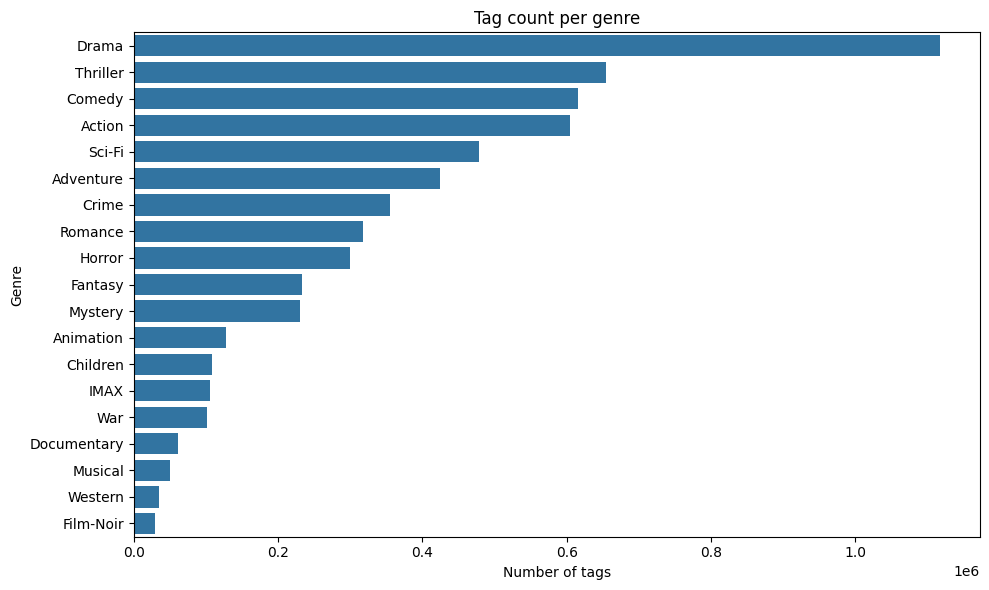

In [16]:
movies_tags = movies.merge(tags, on="movieId", how="left")
tags_per_genre = movies_tags.dropna(subset=["tag"]).assign(
    genre=movies_tags["genres"].str.split()
).explode("genre").groupby("genre")["tag"].count().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=tags_per_genre.values, y=tags_per_genre.index)
plt.title("Tag count per genre")
plt.xlabel("Number of tags")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

## Genres per decade
Since we talked about the movies over the years, the last plot will be a heatmap showing the production of different genres over the decades. We can see quite clearly how Drama has been on the top pretty much every decade and exploded in the 2010s, followed by comedy, which is probably among the cheaper genres to produce since it's based mostly on performance and scriptwriting rather than expensive effects and props. We see a great jump for documentaries and thrillers in the 2000s and also a noticeable increase in romance and horror movies which signals an interest in both knowledge and strong feelings in the audience. 

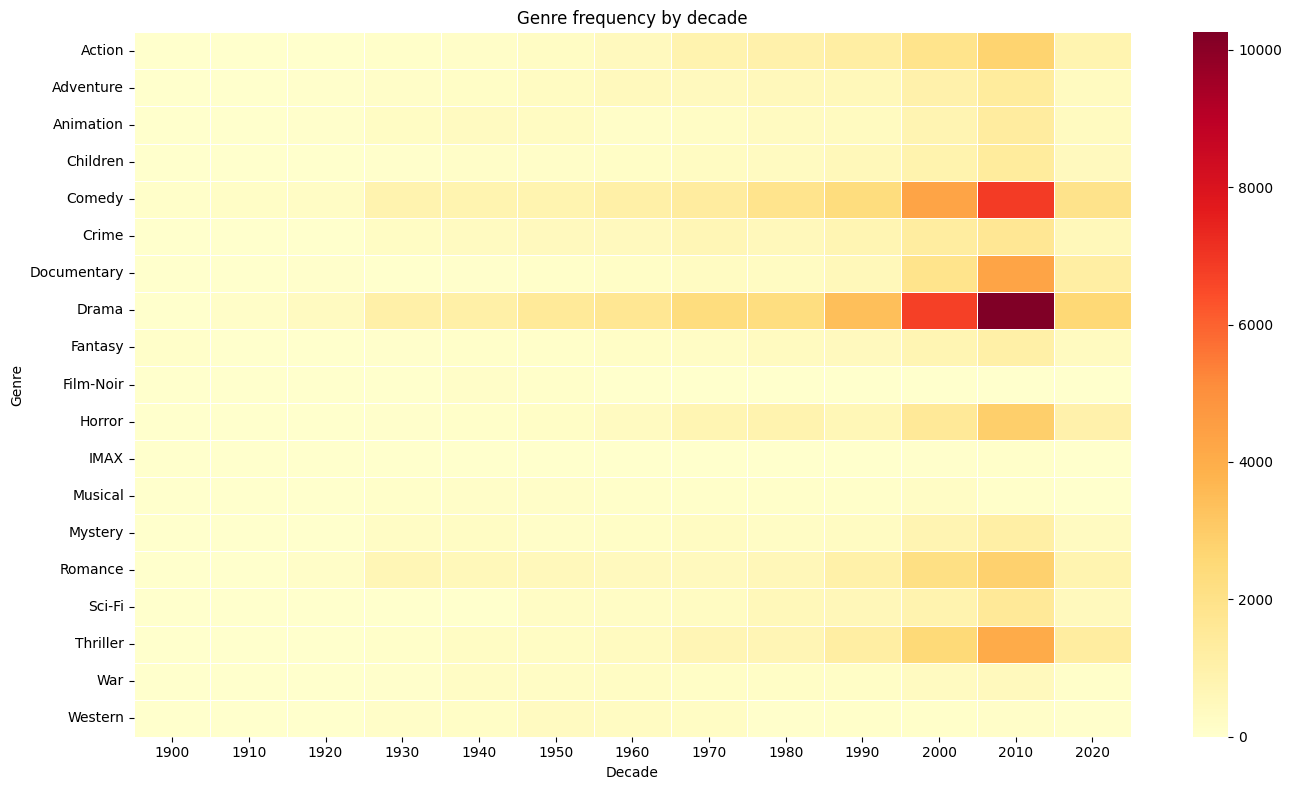

In [17]:
movies_decades = movies.copy()
movies_decades["decade"] = (movies_decades["year"] // 10 * 10).astype("Int64")
movies_decades = movies_decades.dropna(subset=["decade"])
movies_decades = movies_decades[movies_decades["decade"] >= 1900]

genre_decade = movies_decades.assign(
    genre=movies_decades["genres"].str.split()
).explode("genre").groupby(["decade", "genre"]).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(genre_decade.T, cmap="YlOrRd", linewidths=0.5)
plt.title("Genre frequency by decade")
plt.xlabel("Decade")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()